# ML workflow

Grid-search models on one feature set for a target, pick the best per model type, evaluate on a held-out test set, and interpret with SHAP.

**Input:** a featurized dataset (output of `create_features_nmr.ipynb`).  
**Output:** best-model tables, an actual-vs-predicted plot, SHAP summary, and NMF-component visualizations.

The search space and metrics come from [`nmrlib`](nmrlib/); `feature_set` is looked up in [`nmrlib.features.feature_sets`](nmrlib/features.py).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.base import clone
from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, KFold, train_test_split

from nmrlib import load_dataset, regression_metrics
from nmrlib.features import feature_sets
from nmrlib.models import grid_search_space

## Available datasets

Registry from [`nmrlib.data`](nmrlib/data.py). Descriptions are hardcoded labels; `found_in` is checked live against the filesystem. The column listing printed after loading (below) is the sanity check that a dataset's contents actually match its description.

In [2]:
from nmrlib import describe_datasets

describe_datasets()

,description,file,found_in
name,,,
alberts_10k,Alberts et al. 10k subset merged with qchem ta...,alberts_nmr_qchem_merged.pkl,Datasets/
alberts_10k_logp,"Alberts 10k with logP; raw spectra, pre-featur...",alberts_merged_10k_with_logp.pkl,Downloads/
alberts_10k_100kdict,Alberts 10k with NMF codes from the dictionary...,alberts_10k_100kdict_nmf_features.pkl,Downloads/
ids_nmr_1k,"IDS NMR corpus, 1k unlabeled spectra for dicti...",ids_nmr_1k.pkl,Downloads/
ids_nmr_10k,"IDS NMR corpus, 10k unlabeled spectra for dict...",ids_nmr_10k.pkl,Downloads/
ids_nmr_100k,"IDS NMR corpus, 100k unlabeled spectra for dic...",ids_nmr_100k.pkl,Downloads/
ids_1k_featurized,IDS 1k fully featurized (115-component NMF + A...,ids_1k_nmf_115_and_other.pkl,Downloads/
ids_1k_tuned_nmf,IDS 1k with tuned-NMF dictionary codes.,ids_nmr_1k_tuned_nmf_features.pkl,Downloads/
gaussian_1k,Gaussian-matched 1k set with NMR spectra.,gaussian_nmr_matched_1k.pkl,Datasets/


## Config

In [3]:
dataset = "qm9_featurizedDatasets/qm9_featurized.pkl"   # registry name or path to a featurized .pkl
target_col = "gap_ev"              # gap_ev | log_p_rdkit | homo_ev | lumo_ev
feature_set = "NMF"                # any key from feature_sets(df)
seed = 42
train_frac, val_frac, test_frac = 0.70, 0.15, 0.15

## Load & split

In [4]:
df = load_dataset(dataset)
feature_cols = feature_sets(df)[feature_set]
print(f"Feature set {feature_set!r}: {len(feature_cols)} columns")
print(f"Columns ({len(df.columns)}): " + ", ".join(map(str, df.columns)))

Loaded /Users/jacknugent/Desktop/yale_chemistry_project/Datasets/qm9_featurized.pkl — 127166 rows x 317 columns
Feature set 'NMF': 93 columns
Columns (317): num_atom, gap_ev, smiles, file_num, atoms, nmr_gas, C_ppm, H_ppm, 13C Number of Shifts, 13C Minimum Shift, 13C Maximum Shift, 13C Mean Shift, 13C Median Shift, 13C Mode Shift, 13C Variance, 13C Standard Deviation, 13C Skewness, 13C Kurtosis, 1H Number of Shifts, 1H Minimum Shift, 1H Maximum Shift, 1H Mean Shift, 1H Median Shift, 1H Mode Shift, 1H Variance, 1H Standard Deviation, 1H Skewness, 1H Kurtosis, fr_Al_COO, fr_Al_OH, fr_Al_OH_noTert, fr_ArN, fr_Ar_COO, fr_Ar_N, fr_Ar_NH, fr_Ar_OH, fr_COO, fr_COO2, fr_C_O, fr_C_O_noCOO, fr_C_S, fr_HOCCN, fr_Imine, fr_NH0, fr_NH1, fr_NH2, fr_N_O, fr_Ndealkylation1, fr_Ndealkylation2, fr_Nhpyrrole, fr_SH, fr_aldehyde, fr_alkyl_carbamate, fr_alkyl_halide, fr_allylic_oxid, fr_amide, fr_amidine, fr_aniline, fr_aryl_methyl, fr_azide, fr_azo, fr_barbitur, fr_benzene, fr_benzodiazepine, fr_bicyclic,

In [5]:
model_df = df.dropna(subset=[target_col] + feature_cols)
print(f"{len(model_df)} / {len(df)} rows have no NaNs in target + features")

X = model_df[feature_cols].astype(float)
y = model_df[target_col].astype(float)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=test_frac, random_state=seed,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_frac / (train_frac + val_frac),
    random_state=seed,
)
print(f"Train {len(X_train)}  |  Val {len(X_val)}  |  Test {len(X_test)}")

127166 / 127166 rows have no NaNs in target + features
Train 89016  |  Val 19075  |  Test 19075


## Hyperparameter search

In [ ]:
search_pipe, param_grid = grid_search_space(len(feature_cols), seed=seed)

cv = KFold(n_splits=5, shuffle=True, random_state=seed)
n_combos = sum(int(np.prod([len(v) for v in g.values()])) for g in param_grid)
print(f"{n_combos} param combos x {cv.get_n_splits()} folds = {n_combos * cv.get_n_splits()} fits")

grid_search = GridSearchCV(
    search_pipe, param_grid, cv=cv, scoring="neg_root_mean_squared_error",
    n_jobs=-1, refit=True,
)
grid_search.fit(X_trainval, y_trainval)
best_pipe = grid_search.best_estimator_
print("Best params:", grid_search.best_params_)

62 param combos x 5 folds = 310 fits


## Best model per type

In [ ]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res["model_type"] = cv_res["param_model"].apply(lambda m: type(m).__name__)
best_per_type = (
    cv_res.sort_values("rank_test_score")
    .drop_duplicates(subset="model_type", keep="first")
)

best_pipes = {}
for _, row in best_per_type.iterrows():
    pipe_clone = clone(search_pipe).set_params(**row["params"])
    pipe_clone.fit(X_trainval, y_trainval)
    best_pipes[row["model_type"]] = {
        "pipeline": pipe_clone,
        "cv_rmse": -row["mean_test_score"],
        "params": row["params"],
    }

print(f"Best pipeline per model type ({len(best_pipes)}):")
for name, info in sorted(best_pipes.items(), key=lambda x: x[1]['cv_rmse']):
    print(f"  {name:35s}  CV RMSE = {info['cv_rmse']:.4f}")

Best pipeline per model type (6):
  HistGradientBoostingRegressor        CV RMSE = 0.6003
  RandomForestRegressor                CV RMSE = 0.6211
  PLSRegression                        CV RMSE = 0.6401
  ElasticNet                           CV RMSE = 0.6401
  LinearRegression                     CV RMSE = 0.6401
  KNeighborsRegressor                  CV RMSE = 0.6506


## Test set — all model types

In [ ]:
overall_best_type = type(grid_search.best_params_["model"]).__name__

rows = []
for model_name, info in best_pipes.items():
    metrics = regression_metrics(y_test, info["pipeline"].predict(X_test))
    rows.append({
        "model_type": model_name,
        "cv_rmse": round(info["cv_rmse"], 4),
        "feature_set": feature_set,
        "n_features": len(feature_cols),
        "target": target_col,
        **metrics,
    })
test_comparison = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
test_comparison

,model_type,cv_rmse,feature_set,n_features,target,rmse,mae,medae,r2
0,HistGradientBoostingRegressor,0.6003,NMF,93,gap_ev,0.586158,0.454464,0.372615,0.628723
1,RandomForestRegressor,0.6211,NMF,93,gap_ev,0.605299,0.468129,0.373012,0.604079
2,LinearRegression,0.6401,NMF,93,gap_ev,0.634212,0.497371,0.427470,0.565353
3,PLSRegression,0.6401,NMF,93,gap_ev,0.634308,0.497423,0.425779,0.565221
4,ElasticNet,0.6401,NMF,93,gap_ev,0.634372,0.497486,0.427637,0.565134
5,KNeighborsRegressor,0.6506,NMF,93,gap_ev,0.635492,0.489535,0.393702,0.563596


## Actual vs predicted (best model)

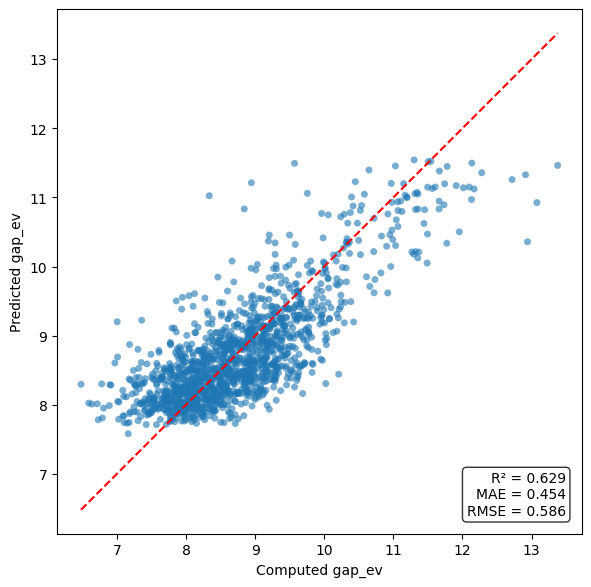

In [ ]:
y_test_pred = best_pipe.predict(X_test)
test_metrics = regression_metrics(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_test_pred, alpha=0.6, s=25, edgecolors="none")
lo = min(y_test.min(), y_test_pred.min())
hi = max(y_test.max(), y_test_pred.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1.5)
ax.set_xlabel(f"Computed {target_col}")
ax.set_ylabel(f"Predicted {target_col}")
ax.set_aspect("equal", adjustable="box")
ax.text(
    0.97, 0.03,
    f"R\u00b2 = {test_metrics['r2']:.3f}\n"
    f"MAE = {test_metrics['mae']:.3f}\n"
    f"RMSE = {test_metrics['rmse']:.3f}",
    transform=ax.transAxes, ha="right", va="bottom",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)
plt.tight_layout()
plt.show()

## SHAP

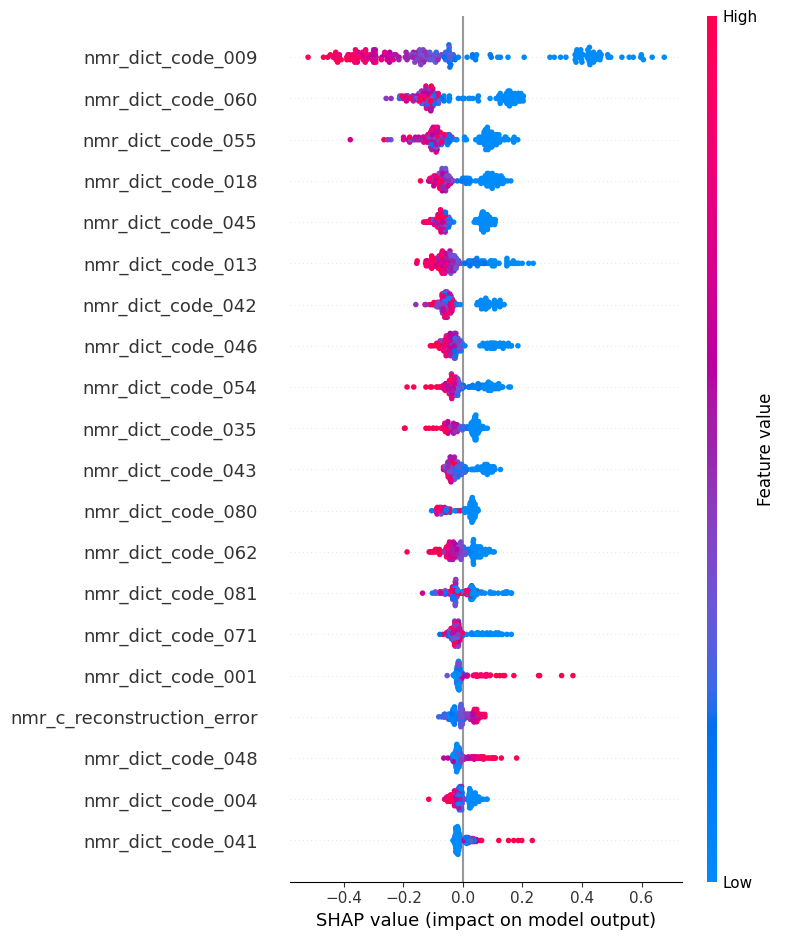

In [ ]:
model_step = best_pipe.named_steps["model"]
scaler_step = best_pipe.named_steps["scaler"]

X_bg = pd.DataFrame(
    scaler_step.transform(X_train.sample(min(200, len(X_train)), random_state=seed)),
    columns=feature_cols,
)
X_explain = pd.DataFrame(
    scaler_step.transform(X_test.iloc[:200]),
    columns=feature_cols,
)

if isinstance(model_step, (RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor)):
    explainer = shap.TreeExplainer(model_step)
    shap_values = explainer.shap_values(X_explain)
elif isinstance(model_step, KNeighborsRegressor):
    bg = shap.sample(X_bg, 50, random_state=seed)
    X_explain = X_explain.iloc[:50]
    explainer = shap.KernelExplainer(model_step.predict, bg)
    shap_values = explainer.shap_values(X_explain)
else:
    explainer = shap.LinearExplainer(model_step, X_bg)
    shap_values = explainer.shap_values(X_explain)

shap.summary_plot(shap_values, X_explain, show=True)

In [ ]:
# mean |SHAP| per feature
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols)
mean_abs_shap.sort_values(ascending=False).head(15)

nmr_dict_code_009    0.274557
nmr_dict_code_060    0.132342
nmr_dict_code_055    0.100032
nmr_dict_code_018    0.076677
nmr_dict_code_045    0.074808
nmr_dict_code_013    0.071952
nmr_dict_code_042    0.067221
nmr_dict_code_046    0.056726
nmr_dict_code_054    0.052891
nmr_dict_code_035    0.042595
nmr_dict_code_043    0.042541
nmr_dict_code_080    0.042258
nmr_dict_code_062    0.040464
nmr_dict_code_081    0.040341
nmr_dict_code_071    0.036344
dtype: float64

## Visualize top NMF components

Maps the highest-|SHAP| NMF codes back to their H/C spectral motifs.

Top NMF components: [9, 60, 55]
Loaded 90 components. Plotting 3 specified components: [9, 60, 55]
H components shape: (90, 1201), grid range: 0.0 to 12.0 ppm
C components shape: (90, 881), grid range: 0.0 to 220.0 ppm
Successfully saved components plot to /Users/jacknugent/Desktop/yale_chemistry_project/figures/top_shap_nmf_components.png


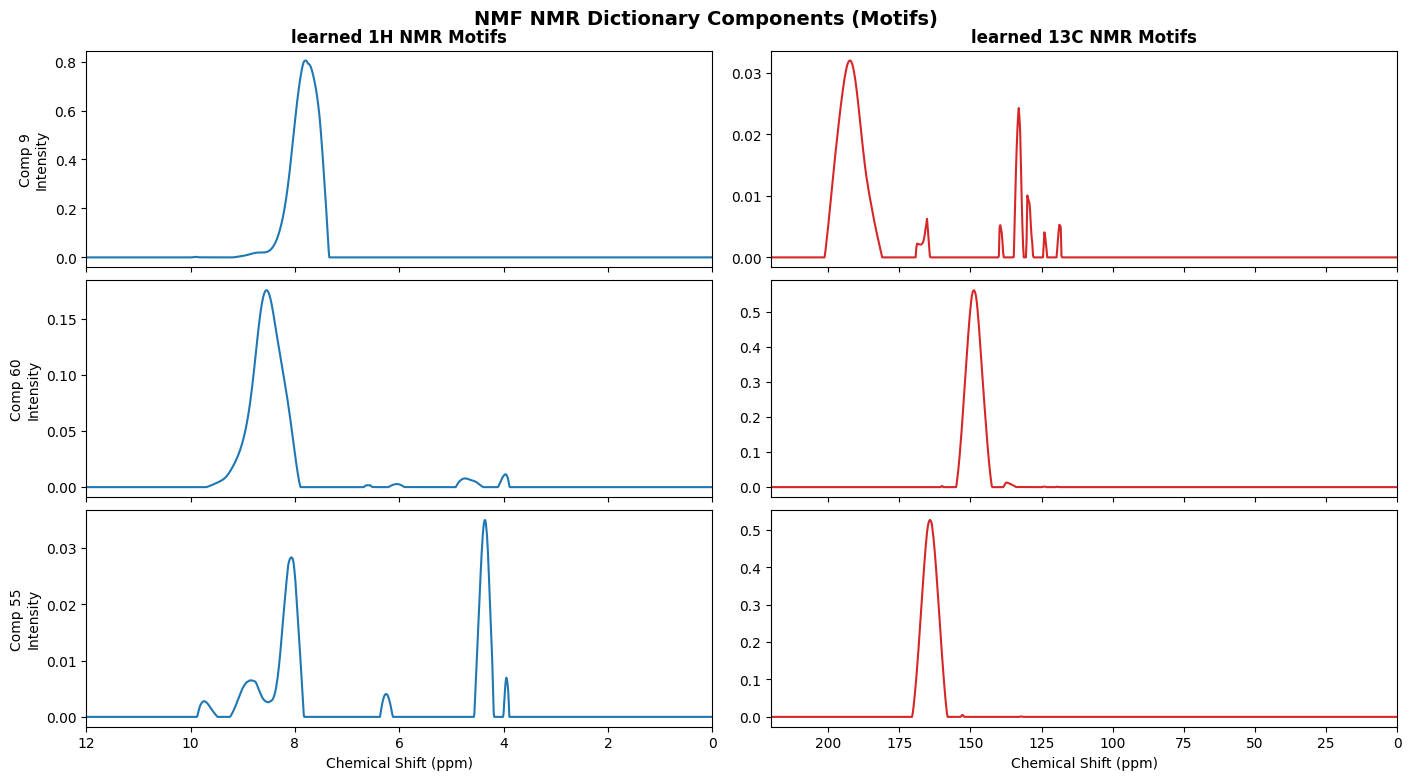

In [ ]:
from pathlib import Path
from plot_nmf_components import plot_nmf_components

# Point this at the NMF dictionary artifact the codes were built from
nmf_dictionary = Path("/Users/jacknugent/Downloads/gap_from_100k_dict/nmf_dictionary_100k.pkl")

# Top codes by mean |SHAP| (strip the nmr_dict_code_ prefix -> component index)
top_codes = [
    int(name.split("_")[-1])
    for name in mean_abs_shap.sort_values(ascending=False).index
    if name.startswith("nmr_dict_code_")
][:3]
print("Top NMF components:", top_codes)

if nmf_dictionary.exists() and top_codes:
    plot_nmf_components(
        model_path=nmf_dictionary,
        comp_indices=top_codes,
        output_plot=Path("figures/top_shap_nmf_components.png"),
    )